<a href="https://colab.research.google.com/github/Yusep-T/data-science-2026/blob/main/Pertemuan9_Yusep_250401020103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Yusep-T/data-science-2026/blob/main/Pertemuan9_Yusep_250401020103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 9 - Algoritma Klasifikasi (Bagian 1)
## Logistic Regression, Decision Trees, Confusion Matrix, Accuracy, Precision, Recall, F1-Score
### Studi Kasus: Prediksi Diagnosis Kanker Payudara (Breast Cancer Wisconsin Dataset)

**Nama  : Yusep Tiana**
**NIM   : 250401020103**

---

**Tujuan Notebook:**

Notebook ini bertujuan membangun dan membandingkan dua model klasifikasi biner untuk memprediksi apakah sebuah tumor bersifat **malignant (ganas)** atau **benign (jinak)**, berdasarkan 30 fitur numerik hasil pengukuran citra digital biopsi.

Model yang dibandingkan:
- **Logistic Regression** — model linear, cocok untuk data dengan hubungan fitur-target yang cenderung linear, dan hasilnya mudah diinterpretasi lewat koefisien.
- **Decision Tree** — model non-linear berbasis aturan (rule-based), hasilnya mudah divisualisasikan sebagai pohon keputusan.

Evaluasi dilakukan menggunakan:
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score

> **Kenapa bukan cuma Accuracy?** Dalam kasus diagnosis medis, kesalahan tipe **False Negative** (pasien sakit tapi diprediksi sehat) jauh lebih berbahaya daripada False Positive. Karena itu **Recall** menjadi metrik yang paling penting untuk diperhatikan di kasus ini, bukan hanya Accuracy.

## 1. Import Library

Bagian ini menyiapkan seluruh tools yang dibutuhkan:
- `pandas`, `numpy` → manipulasi dan struktur data
- `matplotlib.pyplot` → visualisasi
- `sklearn.datasets` → sumber dataset
- `sklearn.model_selection` → split data training/testing
- `sklearn.preprocessing` → standardisasi skala fitur
- `sklearn.linear_model` & `sklearn.tree` → algoritma Logistic Regression & Decision Tree
- `sklearn.metrics` → alat evaluasi model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

## 2. Load Dataset

Dataset yang digunakan adalah **Breast Cancer Wisconsin (Diagnostic)**, dataset bawaan scikit-learn.
Setiap baris merepresentasikan hasil pengukuran karakteristik sel dari citra digital biopsi (radius, texture, perimeter, area, smoothness, dst), dengan target:
- **0 = malignant** (ganas)
- **1 = benign** (jinak)

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape Dataset :", X.shape)

print("\nDistribusi Target")
print(pd.Series(y).value_counts())

print("\nNama Target (index sesuai kode di atas: 0 -> malignant, 1 -> benign)")
print(data.target_names)

X.head()

Shape Dataset : (569, 30)

Distribusi Target
1    357
0    212
Name: count, dtype: int64

Nama Target (index sesuai kode di atas: 0 -> malignant, 1 -> benign)
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Exploratory Data Analysis (EDA) — Correlation Matrix

Sebelum masuk ke modeling, kita lihat dulu korelasi antar fitur. Ini membantu memahami fitur mana yang punya hubungan kuat satu sama lain (multikolinearitas), yang relevan khususnya untuk model linear seperti Logistic Regression.

Warna merah = korelasi positif kuat, warna biru = korelasi negatif kuat.

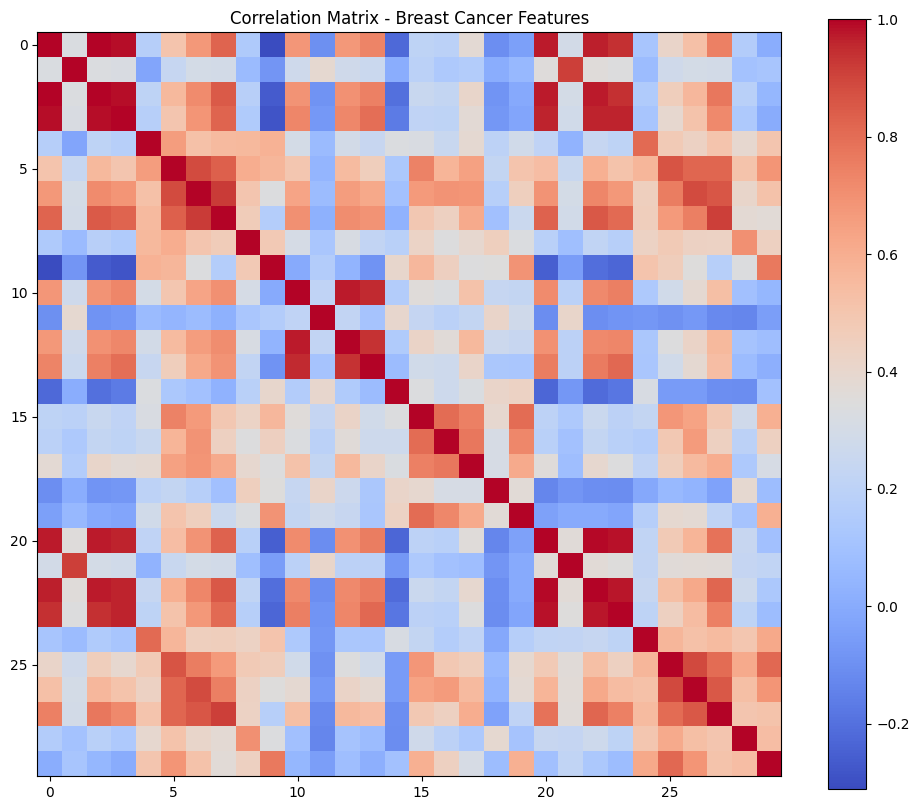

In [ ]:
plt.figure(figsize=(12,10))
corr = X.corr()

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Matrix - Breast Cancer Features")
plt.show()

## 4. Split Data (Training & Testing)

Data dibagi menjadi 80% data training dan 20% data testing. Parameter `stratify=y` digunakan supaya proporsi kelas malignant/benign tetap seimbang di kedua bagian data, dan `random_state=42` supaya hasil split selalu sama setiap kali notebook dijalankan ulang (reproducible).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran data training :", X_train.shape)
print("Ukuran data testing  :", X_test.shape)

Ukuran data training : (455, 30)
Ukuran data testing  : (114, 30)


## 5. Feature Scaling

Dilakukan **standardisasi** (mean = 0, std = 1) menggunakan `StandardScaler`.

> **Kenapa perlu?** Logistic Regression sensitif terhadap skala fitur — fitur dengan rentang nilai besar (misalnya `area`) bisa mendominasi fitur dengan rentang kecil (misalnya `smoothness`) meskipun sebenarnya sama pentingnya. Scaler di-*fit* hanya pada data training (`fit_transform`), lalu diterapkan ke data testing (`transform` saja) — ini penting supaya tidak terjadi *data leakage* dari data testing ke proses training.
>
> Catatan: Decision Tree di bagian selanjutnya sengaja **tidak** menggunakan data yang di-scaling, karena algoritma berbasis pohon (split berdasarkan threshold per fitur) tidak sensitif terhadap skala data.

In [ ]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 6. Model 1 — Logistic Regression

`max_iter=5000` diberikan agar algoritma optimisasi punya cukup iterasi untuk konvergen, mengingat jumlah fitur yang cukup banyak (30 fitur). `random_state=42` ditambahkan untuk memastikan hasil training konsisten/reproducible setiap kali dijalankan ulang.

In [ ]:
log_model = LogisticRegression(max_iter=5000, random_state=42)

log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

### 6.1 Interpretasi Koefisien

Koefisien Logistic Regression menunjukkan arah dan kekuatan pengaruh tiap fitur terhadap probabilitas kelas target (`1 = benign`).
- Koefisien **positif** → semakin besar nilai fitur, semakin besar peluang tumor diprediksi **benign**.
- Koefisien **negatif** → semakin besar nilai fitur, semakin besar peluang tumor diprediksi **malignant**.

Diurutkan berdasarkan nilai absolut terbesar (fitur paling berpengaruh, tanpa memandang arahnya).

In [ ]:
coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Koefisien",
    key=abs,
    ascending=False
)

coef_df.head(10)

,Fitur,Koefisien
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


### 6.2 Evaluasi Logistic Regression

`display_labels` dan `target_names` ditambahkan pada confusion matrix dan classification report supaya label kelas tampil sebagai **malignant/benign**, bukan angka 0/1 — lebih mudah dibaca saat presentasi.

=== Logistic Regression ===

Confusion Matrix
[[41  1]
 [ 1 71]]


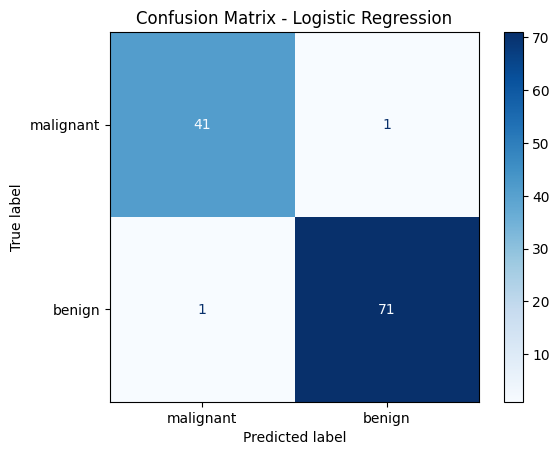


Accuracy  : 0.9824561403508771
Precision : 0.9861111111111112
Recall    : 0.9861111111111112
F1 Score  : 0.9861111111111112

Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
print("=== Logistic Regression ===")

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, y_pred_log)
print(cm)

disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print("\nAccuracy  :", accuracy_score(y_test, y_pred_log))
print("Precision :", precision_score(y_test, y_pred_log))
print("Recall    :", recall_score(y_test, y_pred_log))
print("F1 Score  :", f1_score(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log, target_names=data.target_names))

## 7. Model 2 — Decision Tree

`max_depth=4` membatasi kedalaman pohon agar tidak terlalu kompleks (menghindari overfitting) dan tetap mudah divisualisasikan/diinterpretasikan. `random_state=42` memastikan hasil training reproducible.

In [ ]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

### 7.1 Visualisasi Pohon Keputusan

Setiap node menunjukkan fitur dan threshold yang dipakai untuk memecah data. Warna node merepresentasikan kecenderungan kelas mayoritas pada node tersebut.

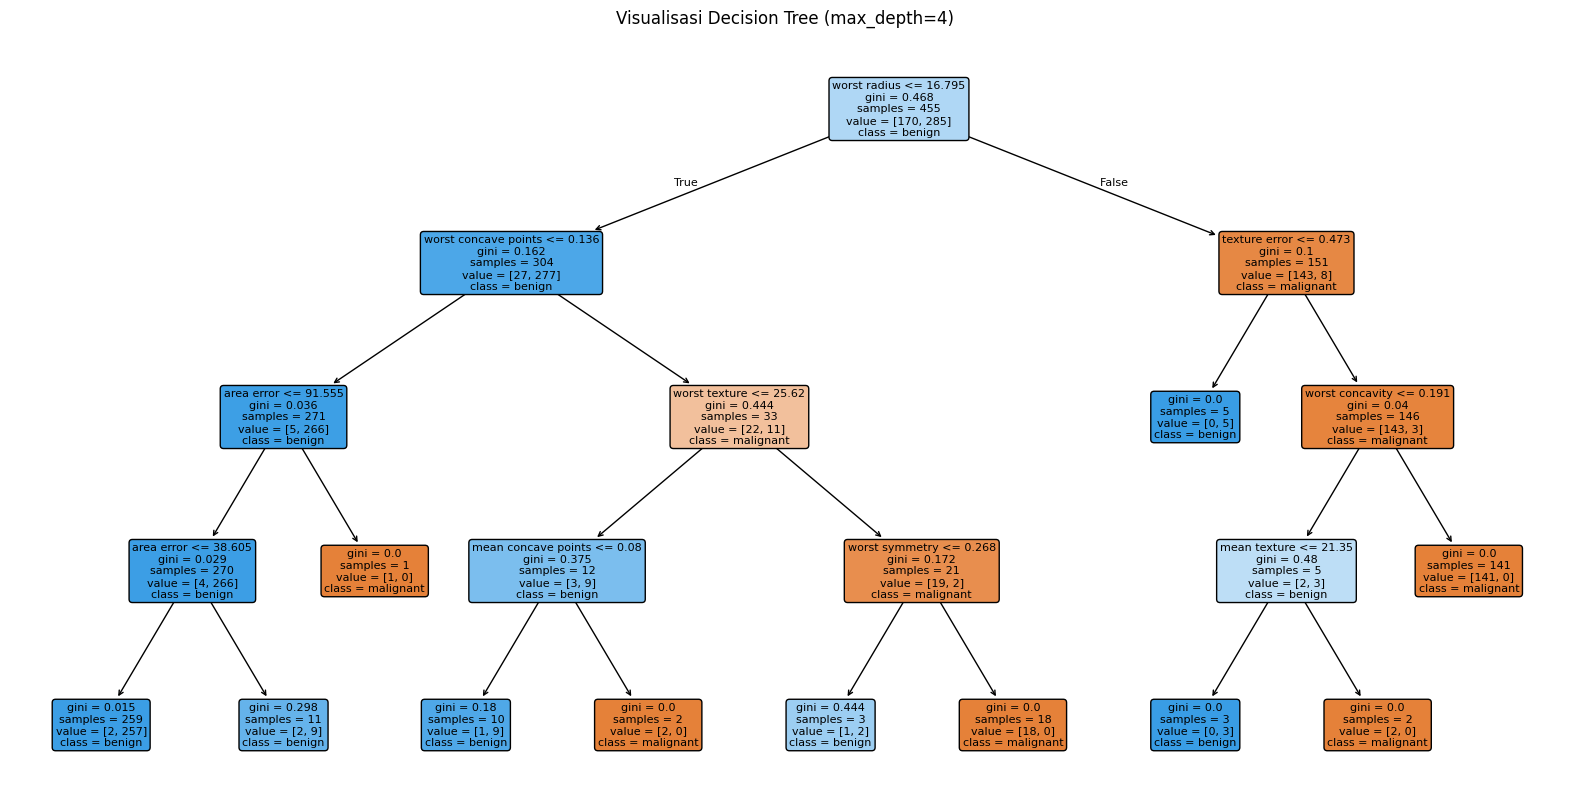

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Visualisasi Decision Tree (max_depth=4)")
plt.show()

### 7.2 Feature Importance

Menunjukkan seberapa besar kontribusi tiap fitur dalam proses pemisahan kelas di seluruh pohon (berbeda dari koefisien Logistic Regression yang menunjukkan arah pengaruh linear).

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
20,worst radius,0.733548
27,worst concave points,0.122028
11,texture error,0.045785
21,worst texture,0.032319
26,worst concavity,0.017161
7,mean concave points,0.013327
13,area error,0.012704
1,mean texture,0.011846
28,worst symmetry,0.011282
3,mean area,0.000000


### 7.3 Evaluasi Decision Tree

=== Decision Tree ===

Confusion Matrix
[[39  3]
 [ 4 68]]


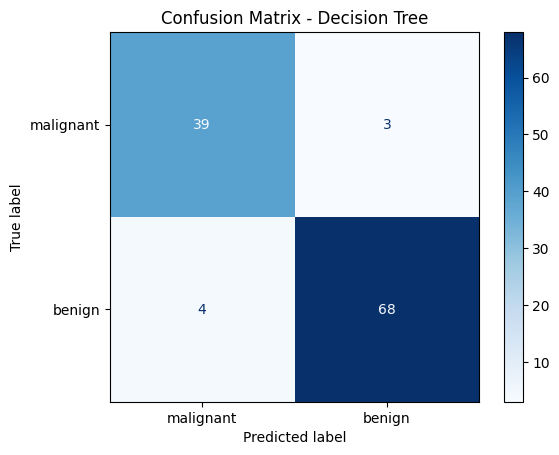


Accuracy  : 0.9385964912280702
Precision : 0.9577464788732394
Recall    : 0.9444444444444444
F1 Score  : 0.951048951048951

Classification Report
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [ ]:
print("=== Decision Tree ===")

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, y_pred_tree)
print(cm)

disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

print("\nAccuracy  :", accuracy_score(y_test, y_pred_tree))
print("Precision :", precision_score(y_test, y_pred_tree))
print("Recall    :", recall_score(y_test, y_pred_tree))
print("F1 Score  :", f1_score(y_test, y_pred_tree))

print("\nClassification Report")
print(classification_report(y_test, y_pred_tree, target_names=data.target_names))

## 8. Perbandingan Performa Model

In [ ]:
hasil = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ]
})

hasil

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.938596,0.957746,0.944444,0.951049


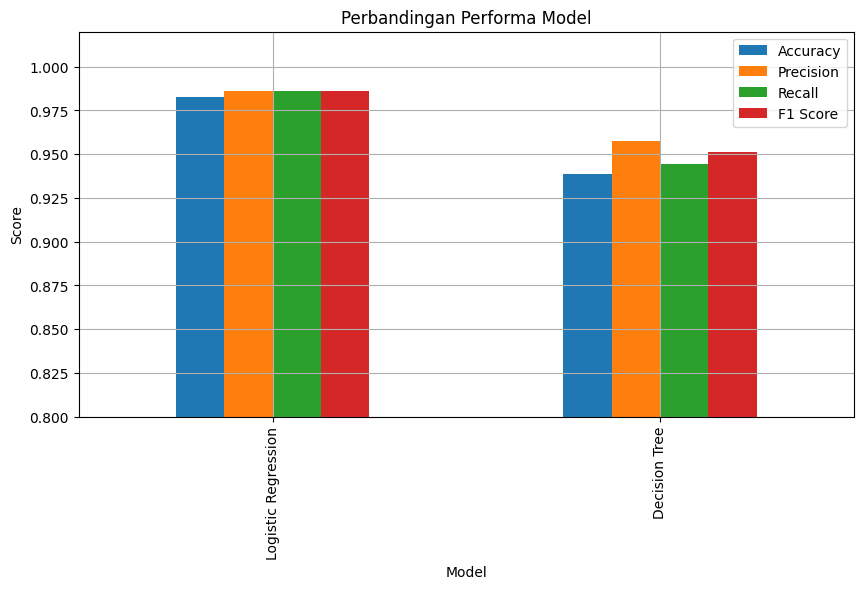

In [ ]:
hasil.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylim(0.8, 1.02)
plt.title("Perbandingan Performa Model")
plt.ylabel("Score")
plt.grid(True)
plt.show()

# 9. Kesimpulan

Berdasarkan hasil pengujian menggunakan **Breast Cancer Wisconsin Dataset**, diperoleh dua model klasifikasi yaitu **Logistic Regression** dan **Decision Tree**.

**Logistic Regression** memiliki nilai Accuracy, Precision, Recall, dan F1-Score yang lebih tinggi dibandingkan **Decision Tree** pada dataset ini — kemungkinan karena hubungan antar fitur terhadap target cenderung bersifat linear, sehingga cocok dengan karakteristik model linear seperti Logistic Regression.

Pada kasus diagnosis kanker, metrik yang paling penting untuk diperhatikan adalah **Recall**, karena tujuannya adalah meminimalkan **False Negative** — kondisi di mana pasien yang sebenarnya menderita kanker (malignant) diprediksi sehat (benign) oleh model. False Negative jauh lebih berisiko dibandingkan False Positive, karena bisa menyebabkan keterlambatan penanganan medis bagi pasien yang sebenarnya membutuhkan.

Dari kedua model ini, **Logistic Regression** menghasilkan Recall yang lebih tinggi dan jumlah False Negative yang lebih sedikit, sehingga secara praktis lebih disarankan untuk kasus diagnosis medis seperti ini — meskipun Decision Tree tetap unggul dari sisi interpretabilitas visual (pohon keputusan yang mudah ditelusuri secara manual).